In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import accuracy_score,classification_report,recall_score,confusion_matrix

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [101]:
df = pd.read_csv('novagen_dataset.csv')
df.head(5)

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [102]:
df.shape
# 22 input features, 1 target

(9549, 23)

In [103]:
df.isnull().sum() 

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

In [104]:
# cleaned dataset
df.duplicated().sum()

np.int64(0)

In [105]:
df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,0.521416,0.990470,0.995183,1.005864,0.998429,1.003351,1.004713,0.989318
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,0.499567,0.815521,0.816653,0.815877,0.821844,0.808800,0.813506,0.815699
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

### No duplicated samples found

In [107]:
#smoking alcohol and medical history contain 0,1,2 ==> replacing them with only 0 & 1 values, either yes or no

df['Smoking'] = df['Smoking'].map({0:0, 1:1,2: 1})
df['Alcohol'] = df['Alcohol'].map({0:0, 1:1,2: 1})
df['MedicalHistory'] = df['MedicalHistory'].map({0:0, 1:1,2: 1})


#convert bool data type to int

df['Diet_Type__Vegan'] = df['Diet_Type__Vegan'].astype(int)
df['Diet_Type__Vegetarian'] = df['Diet_Type__Vegetarian'].astype(int)
df['Blood_Group_AB'] = df['Blood_Group_AB'].astype(int)
df['Blood_Group_B'] = df['Blood_Group_B'].astype(int)
df['Blood_Group_O'] = df['Blood_Group_O'].astype(int)
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,0,1,1,0,0
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,1,2,0,0,1,0,0
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,1,0,0,0,0
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,1,0,1,0,0,1,0
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,0,1,0,1,0


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

# EDA

## Univariate analysis

Text(0.5, 1.0, 'Age Distribution of volunteers')

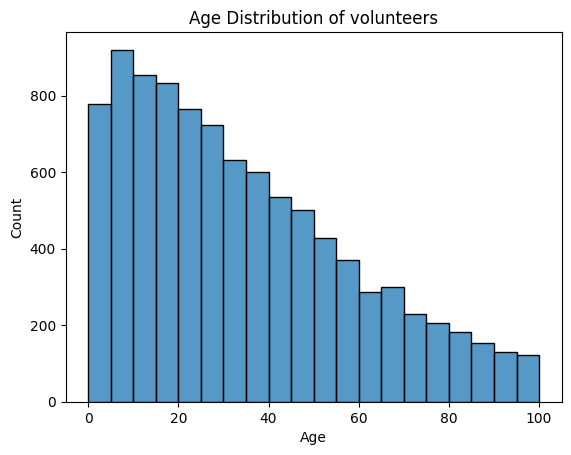

In [109]:
sns.histplot(
    data = df, 
    x = 'Age',
    bins = 20
)

plt.title("Age Distribution of volunteers") #highest num of volunteers are bw 0-30

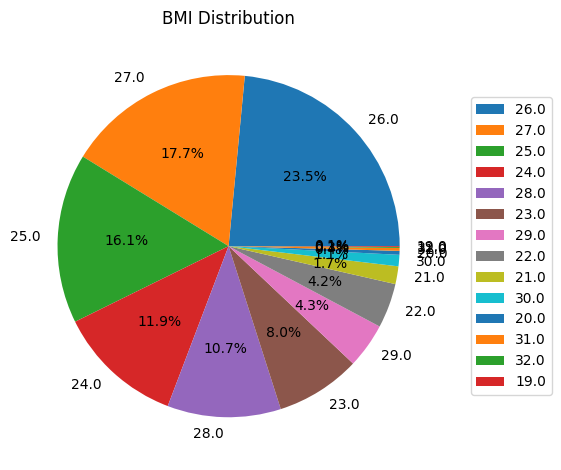

In [110]:
plt.pie(
    x = df['BMI'].value_counts(),
    labels = df['BMI'].value_counts().index.to_list(),
    autopct = "%1.1f%%"
)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),  # X is outside the right edge, Y is centered

)
plt.title("BMI Distribution")
plt.tight_layout()
plt.show()

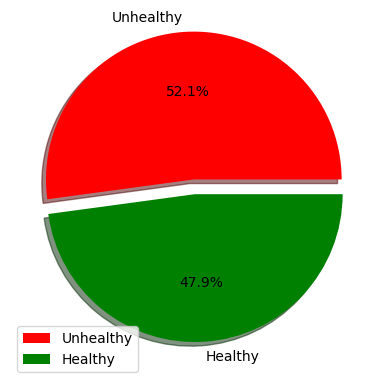

In [111]:
plt.pie(
    x =df['Target'].value_counts(),
    labels = ['Unhealthy','Healthy'],
    autopct = "%1.1f%%",
    shadow = True,
    colors = ['red','g'],
    explode = [0.1,0]
)

plt.legend()
plt.savefig('health_distribution')
plt.show()

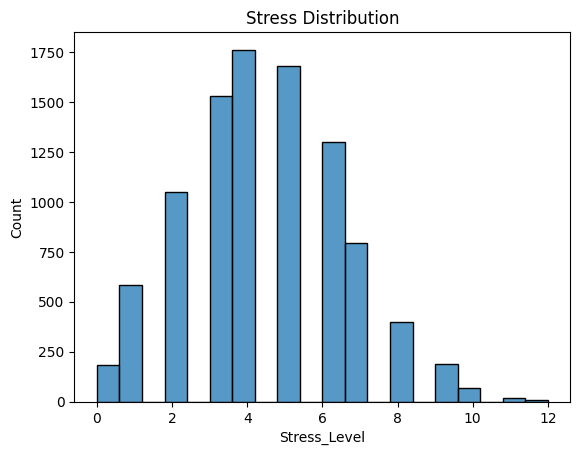

In [112]:
sns.histplot(
    x =df['Stress_Level'],
    bins = 20
)
plt.title("Stress Distribution")
plt.show()

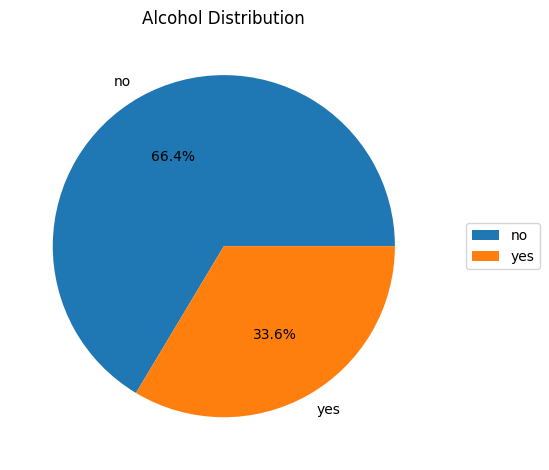

In [113]:
plt.pie(
    x = df['Alcohol'].value_counts(),
    labels = ['no','yes'],
    autopct = "%1.1f%%",
)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),  # X is outside the right edge, Y is centered

)
plt.title("Alcohol Distribution")
plt.tight_layout()
plt.show()

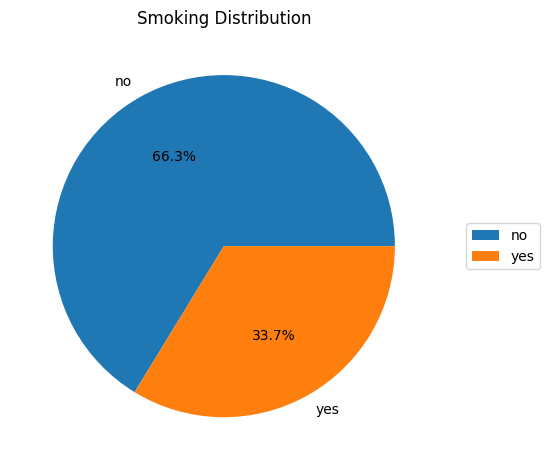

In [114]:
plt.pie(
    x = df['Smoking'].value_counts(),
    labels = ['no','yes'],
    autopct = "%1.1f%%"
)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),  # X is outside the right edge, Y is centered

)
plt.title("Smoking Distribution")
plt.tight_layout()
plt.show()

## Bivariate analysis

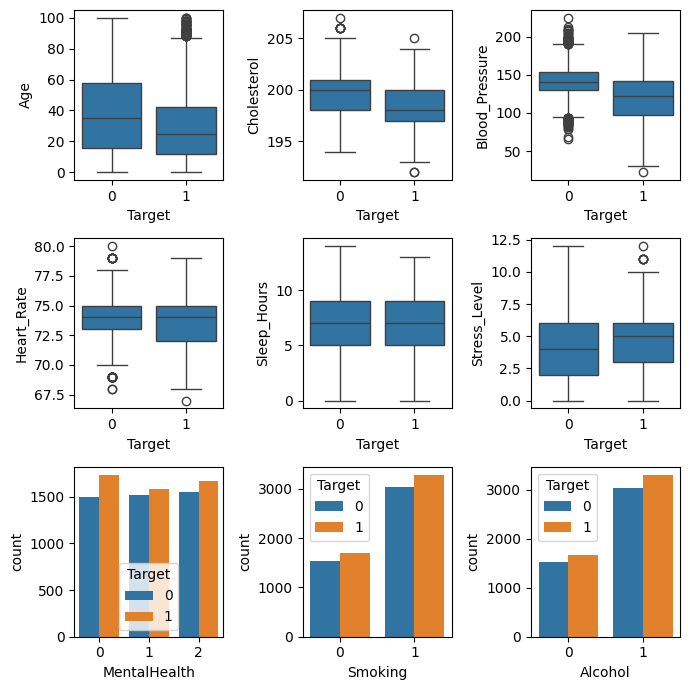

In [115]:
plt.figure(figsize = (7,7))


plt.subplot(3,3,1)
sns.boxplot(
    x = df['Target'],
    y = df['Age']
)

plt.subplot(3,3,2)
sns.boxplot(
    x = df['Target'],
    y = df['Cholesterol']
)

plt.subplot(3,3,3)
sns.boxplot(
    x = df['Target'],
    y = df['Blood_Pressure']
)

plt.subplot(3,3,4)
sns.boxplot(
    x = df['Target'],
    y = df['Heart_Rate']
)

plt.subplot(3,3,5)
sns.boxplot(
    x = df['Target'],
    y = df['Sleep_Hours']
)

plt.subplot(3,3,6)
sns.boxplot(
    x = df['Target'],
    y = df['Stress_Level']
)

plt.subplot(3,3,7)
sns.countplot(
    x = df['MentalHealth'],
    hue = df['Target']
)

plt.subplot(3,3,8)
sns.countplot(
    x = df['Smoking'],
    hue = df['Target']
)

plt.subplot(3,3,9)
sns.countplot(
    x = df['Alcohol'],
    hue = df['Target']
)

plt.tight_layout()
plt.savefig('categories_distribution_charts')

<Axes: xlabel='Allergies', ylabel='count'>

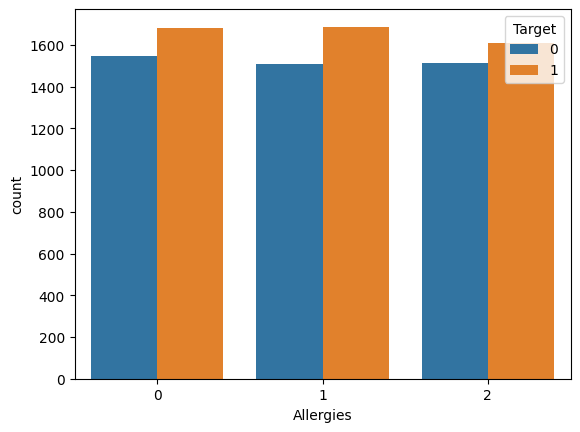

In [116]:
sns.countplot(
    data = df,
    x = 'Allergies', 
    hue = 'Target'
)

<Axes: xlabel='MedicalHistory', ylabel='count'>

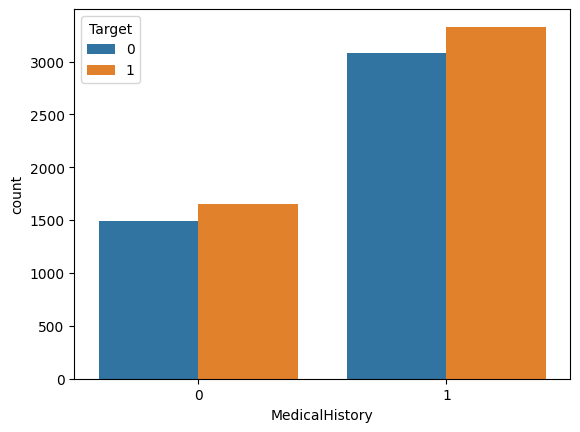

In [117]:
sns.countplot(
    data = df,
    x = 'MedicalHistory',
    hue = 'Target'
)

<Axes: xlabel='Age', ylabel='BMI'>

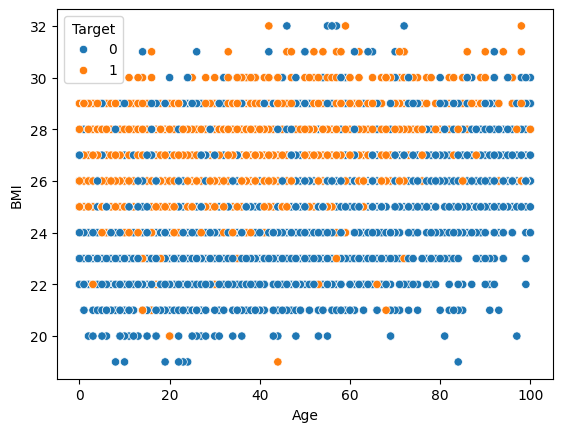

In [118]:
sns.scatterplot(
    data = df,
    x = 'Age', 
    y = 'BMI',
    hue = 'Target'
)

In [119]:
#correaltion heatmap

num_cols = df.select_dtypes(
    include = 'number'
)
num_cols.columns

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
       'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
       'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
       'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type__Vegan',
       'Diet_Type__Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
       'Blood_Group_O'],
      dtype='object')

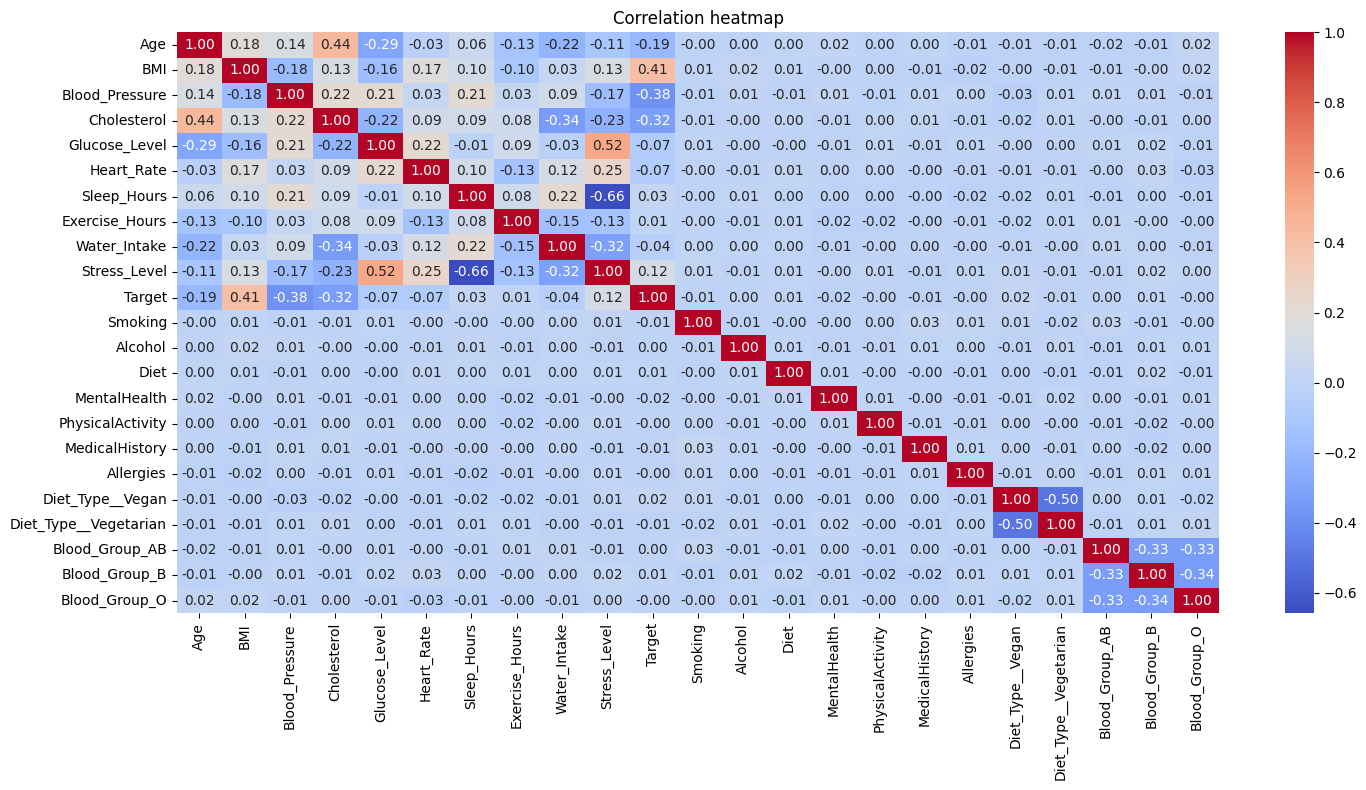

In [120]:
corr_matrix = num_cols.corr()
plt.figure(figsize = (15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = 'coolwarm'
)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap')

<Axes: >

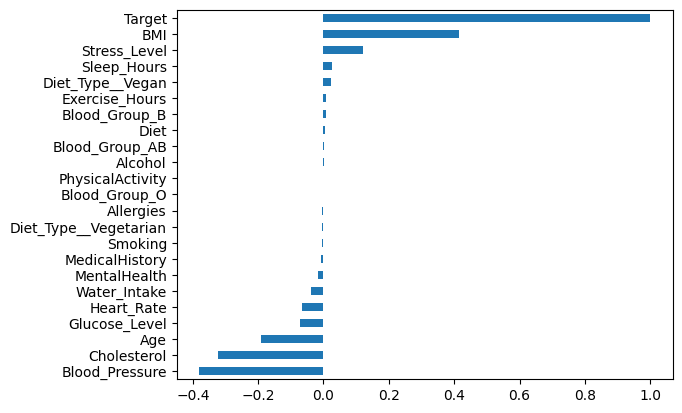

In [59]:
# Correaltion with target

corr_target = df.corr()['Target'].sort_values()

corr_target.plot(kind='barh')

# Baseline Model

In [60]:
X = df.drop(columns = ['Target','Allergies'])
y = df['Target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [61]:
lr = LogisticRegression(max_iter = 10000)

lr.fit(X_train, y_train)

y_test_pred = lr.predict(X_test)
y_train_pred = lr.predict(X_train)

print("accuracy score: " , accuracy_score(y_test, y_test_pred))
print("accuracy score: " , accuracy_score(y_train, y_train_pred))

accuracy score:  0.8198952879581152
accuracy score:  0.8145045162979447


# Feature engineering

In [62]:
#replace bmi and stress_level with their squares
df['BMI_Squared'] = df['BMI']**2
df['Stress_Level_Squared'] = df['Stress_Level']**2

In [63]:
X = df.drop(columns = ['Target','Allergies','BMI'])
y = df['Target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

lr = LogisticRegression(max_iter = 10000)

lr.fit(X_train, y_train)

y_test_pred = lr.predict(X_test)
y_train_pred = lr.predict(X_train)

print("accuracy score: " , accuracy_score(y_test, y_test_pred))
print("accuracy score: " , accuracy_score(y_train, y_train_pred))

accuracy score:  0.830890052356021
accuracy score:  0.8194789893965179


In [64]:
#only a slight change is observed

# Cross Validation

In [65]:
X = df.drop(columns = ['Target','Allergies'])
y = df['Target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2,stratify = y, random_state = 42
)

In [66]:
num_cols = X.select_dtypes(include = ["number"]).columns

In [67]:
#scaling

preprocess = ColumnTransformer(
    [("scaler", StandardScaler(), num_cols)]
)

## SVC

In [70]:
base_svc = SVC(class_weight = 'balanced')

pipe_svc = Pipeline(
    [("preprocess", preprocess),
     ("model", base_svc)]
)

params_grid = {
    'model__C': [0.001,0.1,0.5,0.8],
    'model__kernel': ['rbf','linear','poly','sigmoid']
}

cv_svc = GridSearchCV(
    estimator = pipe_svc,
    param_grid = params_grid,
    cv = 5, 
    scoring = "recall",
    verbose = 2,
    n_jobs = -1
)

cv_svc.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'model__C': [0.001, 0.1, ...], 'model__kernel': ['rbf', 'linear', ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaler', ...)]"


In [71]:
print(cv_svc.best_params_)

{'model__C': 0.8, 'model__kernel': 'rbf'}


In [73]:
best_model_svc = cv_svc.best_estimator_
y_pred_svc = best_model_svc.predict(X_test)

print('accuraccy: ', accuracy_score(y_test, y_pred_svc))
print('recall: ', recall_score(y_test, y_pred_svc))
print('classification report:\n', classification_report(y_test, y_pred_svc))

accuraccy:  0.937696335078534
recall:  0.9518072289156626
classification report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93       914
           1       0.93      0.95      0.94       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910



## Decision Tree

In [75]:
base_dtc = DecisionTreeClassifier(class_weight = 'balanced')    

pipe_dtc = Pipeline(
    [("preprocessor", preprocess),
    ("model", base_dtc)]
)


param_grid_dtc = {
    'model__ccp_alpha' : [0.001,0.1,0.3,0.5],
    'model__max_depth' : [4,6,8,12],
    'model__min_samples_split': [10,20,35,50],
    'model__random_state' : [42]
}

grid_dtc = GridSearchCV(
    estimator = pipe_dtc,
    param_grid = param_grid_dtc,
    cv = 5, 
    scoring = 'recall',
    verbose = 2,
    n_jobs = -1
)

grid_dtc.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'model__ccp_alpha': [0.001, 0.1, ...], 'model__max_depth': [4, 6, ...], 'model__min_samples_split': [10, 20, ...], 'model__random_state': [42]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaler', ...)]"


In [76]:
print(grid_dtc.best_params_)

{'model__ccp_alpha': 0.001, 'model__max_depth': 12, 'model__min_samples_split': 10, 'model__random_state': 42}


In [77]:
best_model_dtc = grid_dtc.best_estimator_

y_pred_dtc = best_model_dtc.predict(X_test)

print('accuraccy: ', accuracy_score(y_test, y_pred_dtc))
print('recall: ', recall_score(y_test, y_pred_dtc))
print('classification report:\n', classification_report(y_test, y_pred_dtc))

accuraccy:  0.9052356020942408
recall:  0.9126506024096386
classification report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90       914
           1       0.91      0.91      0.91       996

    accuracy                           0.91      1910
   macro avg       0.91      0.90      0.91      1910
weighted avg       0.91      0.91      0.91      1910



## Naive Bayes

In [79]:
base_model_gnb = GaussianNB()

pipe_gnb = Pipeline([
    ('preprocessor', preprocess),
    ('model', base_model_gnb)
])

grid_gnb = GridSearchCV(
    estimator = pipe_gnb,
    param_grid = {},
    cv = 5,
    scoring = 'recall',
    n_jobs = -1,
    verbose = 2
)

grid_gnb.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...aussianNB())])
,param_grid,{}
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaler', ...)]"


In [80]:
best_model_gnb = grid_gnb.best_estimator_

y_pred_gnb = best_model_gnb.predict(X_test)

print('accuraccy: ', accuracy_score(y_test, y_pred_gnb))
print('recall: ', recall_score(y_test, y_pred_gnb))
print('classification report:\n', classification_report(y_test, y_pred_gnb))

accuraccy:  0.812565445026178
recall:  0.8273092369477911
classification report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910



# Ensemble Learning

## Random forest classifier

In [83]:
base_model_rf = RandomForestClassifier(oob_score = True,class_weight = 'balanced')

pipe_rf = Pipeline([
    ('preprocessor', preprocess),
    ('model', base_model_rf)
])

param_grid_rf = {
    'model__n_estimators': [201,401,601],
    'model__ccp_alpha' : [0.001,0.1,0.3],
    'model__max_depth' : [4,6,8],
    'model__min_samples_split': [10,20],
    'model__max_features': ['sqrt'],
    'model__random_state' : [42]
}

grid_rf = RandomizedSearchCV(
    estimator = pipe_rf,
    param_distributions = param_grid_rf,
    n_iter = 15,
    scoring = 'recall',
    n_jobs = -1,
    verbose = 2
)

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,Pipeline(step...score=True))])
,param_distributions,"{'model__ccp_alpha': [0.001, 0.1, ...], 'model__max_depth': [4, 6, ...], 'model__max_features': ['sqrt'], 'model__min_samples_split': [10, 20], ...}"
,n_iter,15
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [86]:
print(grid_rf.best_params_)

{'model__random_state': 42, 'model__n_estimators': 201, 'model__min_samples_split': 20, 'model__max_features': 'sqrt', 'model__max_depth': 8, 'model__ccp_alpha': 0.001}


In [85]:
best_model_rf = grid_rf.best_estimator_

y_pred_rf = best_model_rf.predict(X_test)

print("accuracy_score: ", accuracy_score(y_test, y_pred_rf))
print("recall_score: ", recall_score(y_test, y_pred_rf))
print("classification report:\n", classification_report(y_test, y_pred_rf))

accuracy_score:  0.8926701570680629
recall_score:  0.9257028112449799
classification report:
               precision    recall  f1-score   support

           0       0.91      0.86      0.88       914
           1       0.88      0.93      0.90       996

    accuracy                           0.89      1910
   macro avg       0.89      0.89      0.89      1910
weighted avg       0.89      0.89      0.89      1910



## Gradient Boosting

In [87]:
gbc = GradientBoostingClassifier(
    n_estimators = 200,
    learning_rate = 0.1,
    subsample = 0.8,
    random_state = 42
)

gbc.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [88]:
y_pred_gbc = gbc.predict(X_test)

print("accuracy_score: ", accuracy_score(y_test, y_pred_gbc))
print("recall_score: ", recall_score(y_test, y_pred_gbc))
print("classification report:\n", classification_report(y_test, y_pred_gbc))

accuracy_score:  0.9361256544502617
recall_score:  0.9578313253012049
classification report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93       914
           1       0.92      0.96      0.94       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910



## Adaboost Classifier

In [95]:
dt_stump = DecisionTreeClassifier(max_depth = 1,random_state = 42)

abc =  AdaBoostClassifier(
    estimator = dt_stump,
    n_estimators = 50,
    random_state = 42
)

abc.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [96]:
y_pred_abc = abc.predict(X_test)

print("accuracy_score: ", accuracy_score(y_test, y_pred_abc))
print("recall_score: ", recall_score(y_test, y_pred_abc))
print("classification report:\n", classification_report(y_test, y_pred_abc))

accuracy_score:  0.8219895287958116
recall_score:  0.8293172690763052
classification report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81       914
           1       0.83      0.83      0.83       996

    accuracy                           0.82      1910
   macro avg       0.82      0.82      0.82      1910
weighted avg       0.82      0.82      0.82      1910



## Voting Classifier

In [97]:
voting_svc = SVC()
voting_dtc = DecisionTreeClassifier(max_depth = 4)
voting_lr = LogisticRegression(max_iter = 10000)

voting_clf = VotingClassifier(
    estimators = [
        ('svc', voting_svc),
        ('dtc', voting_dtc),
        ('lr', voting_lr)
    ],
    voting = 'hard'
)

voting_clf.fit(X_train, y_train)

,estimators,"[('svc', ...), ('dtc', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


In [98]:
y_pred_voting = abc.predict(X_test)

print("accuracy_score: ", accuracy_score(y_test, y_pred_voting))
print("recall_score: ", recall_score(y_test, y_pred_voting))
print("classification report:\n", classification_report(y_test, y_pred_voting))

accuracy_score:  0.8219895287958116
recall_score:  0.8293172690763052
classification report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81       914
           1       0.83      0.83      0.83       996

    accuracy                           0.82      1910
   macro avg       0.82      0.82      0.82      1910
weighted avg       0.82      0.82      0.82      1910



## Results

| Model                | Recall |
|----------------------|:------:|
| Logistic Regression  | 81.9%  |
| SVC                  | 95.18% |
| Random Forest        | 92.5%  |
| Gradient Boosting    | 95.8%  |
| Voting Classifier    | 82.93% |

### Hence for NovaGen labs we'll use Gradient Boosting

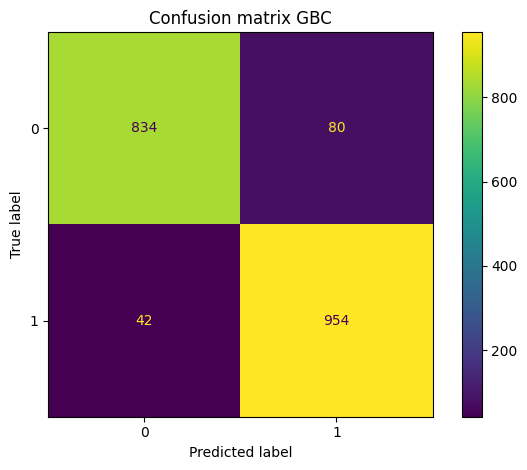

In [128]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_gbc, labels = gbc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=gbc.classes_)
disp.plot()
plt.title("Confusion matrix GBC")
plt.tight_layout()
plt.savefig("cm_gbc")

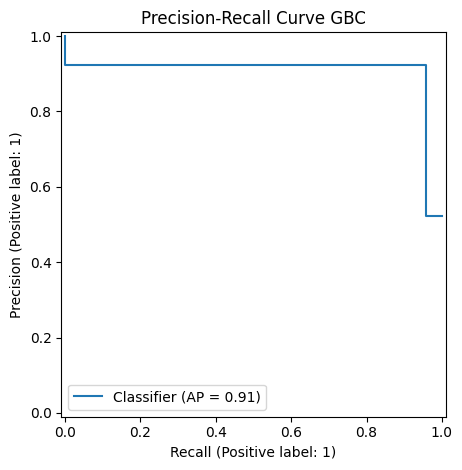

In [130]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

prc = precision_recall_curve(y_test, y_pred_gbc)
PrecisionRecallDisplay.from_predictions(y_test,y_pred_gbc)
plt.title("Precision-Recall Curve GBC")
plt.tight_layout()
plt.savefig("precision_recall_curve_gbc")
plt.show()

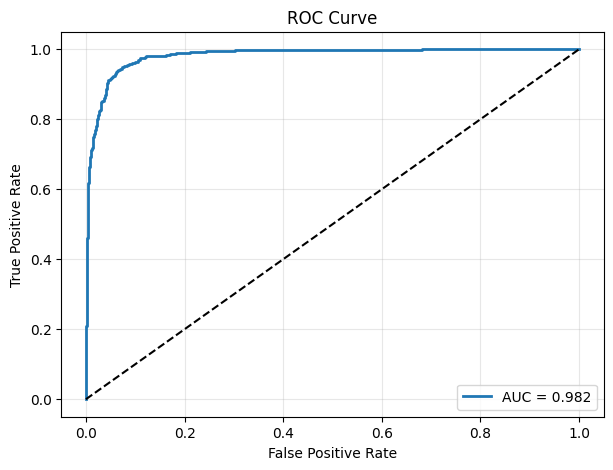

In [163]:
from sklearn.metrics import roc_curve, auc

# probability predictions
y_prob = gbc.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, linewidth=2,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(alpha=0.3)
plt.savefig("roc_curve")
plt.show()

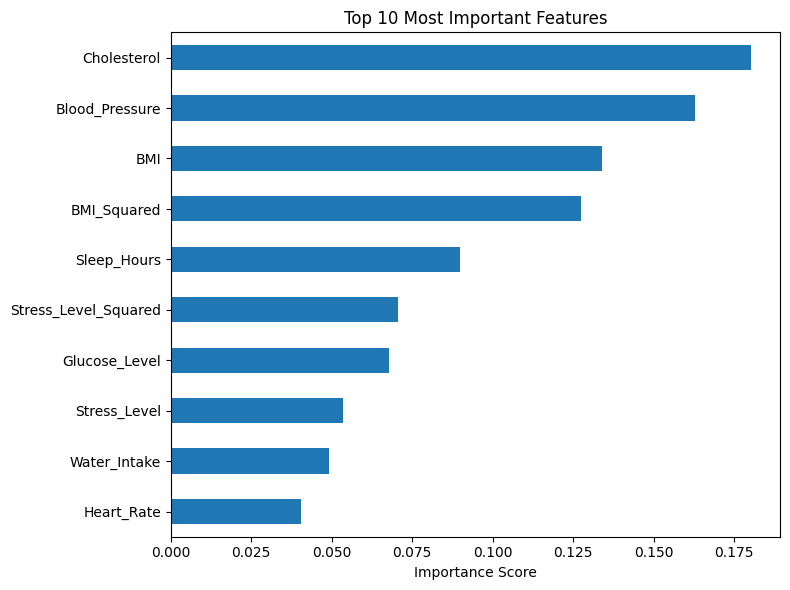

In [162]:
feature_importance = pd.Series(
    gbc.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values()

plt.figure(figsize=(8,6))

feature_importance.tail(10).plot(kind="barh")

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.savefig("most_important_features")
plt.show()

In [131]:
import joblib

joblib.dump(gbc, 'NovaGen_best_model_gbc.joblib')

['NovaGen_best_model_gbc.joblib']